# Vol 27 — Advanced VaR/ES Risk Desk

**問い:** そのVaRは信頼できるか——backtest、条件付きボラ、尾部、リスク分解、P&L explainで検証する。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

vol.08のhistorical/normal VaRを起点に、Kupiec POFとChristoffersen条件付き被覆で1日VaRを検定し、Basel traffic lightで資本乗数を定量化する。GARCH条件付きボラでFHSを組み、EWMA条件付きσでplain-HSより被覆を改善する。POT/GPDで尾部VaR/ESを閉形式に外挿し、Euler配分でmarginal/component/incremental VaRとsimulation ES寄与を厳密加法的に分解し、delta-gamma-vega Taylorとfull revaluationのP&L explainとlimit監視でdesk日次レポートを組み立てる。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'risk_desk_scenarios.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 27
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=27 digest=25151c5b284d2776 arrays=46


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

alloc_normal_var: 77.52904630663974
alpha: 0.99
christoffersen_ind_lr_clustered: 9.894654433330203
christoffersen_ind_lr_iid: 0.008064537982836129
christoffersen_ind_pvalue_clustered: 0.00165759575466473
christoffersen_ind_pvalue_iid: 0.9284439448072724
clustered_basel_zone: yellow
desk_report_es: 89.2145706813487
desk_report_var: 77.52904630663974
euler_additivity_error: 0.0
euler_es_additivity_error: 0.0
evt_alpha: 0.999
evt_es: 20.753067047383286
evt_es_identity_error: 0.0
evt_threshold: 5.0
evt_var: 15.949662940402645
fhs_constant_vol_error: 0.0
fhs_var_constant: 0.04886253563711847
fhs_violation_rate: 0.01
gpd_beta_hat: 0.9332212999765327
gpd_beta_true: 1.0
gpd_n_exceedances: 500
gpd_xi_hat: 0.24567805084324695
gpd_xi_true: 0.2
hs_violation_rate: 0.0145
kupiec_size_rejection_rate: 0.05
kupiec_size_zscore: 0.0
taylor_delta_only: 29.343901557687268
taylor_delta_only_half: 14.671950778843634
taylor_delta_residual: 11.690588536237144
taylor_delta_residual_half: 5.630239148711208
taylo

## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS kupiec_size_calibration 0.0 iid rejection rate within z < 3 of nominal 5% (binomial SE, 400 replications)
PASS christoffersen_detects_clustering 0.00165759575466473 clustered LR_ind p-value < 0.05 and LR_ind statistic exceeds the iid series
PASS fhs_constant_vol_identity 0.0 <= 1e-12
PASS fhs_coverage_improvement 0.01 |FHS violation rate - (1-alpha)| < |plain-HS violation rate - (1-alpha)|
PASS gpd_parameter_recovery 0.04567805084324694 |xi_hat - xi| <= 0.1 and |beta_hat/beta - 1| <= 0.15
PASS evt_var_es_identity 0.0 <= 1e-12
PASS euler_additivity_normal 0.0 <= 1e-12
PASS marginal_fd_consistency 1.027118008182688e-09 analytic vs central-difference marginals, relative error <= 1e-6
PASS euler_es_additivity_sim 0.0 sum(ES components) == total historical ES and matches committed array, <= 1e-12
PASS pnl_explain_taylor_ordering 0.3900125643060548 dgv residual < delta-only residual; both shrink when moves halve
PASS desk_report_reproducible 0.0 desk-report VaR equals Euler component su

## iid vs クラスタ型 exceedance系列

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED 

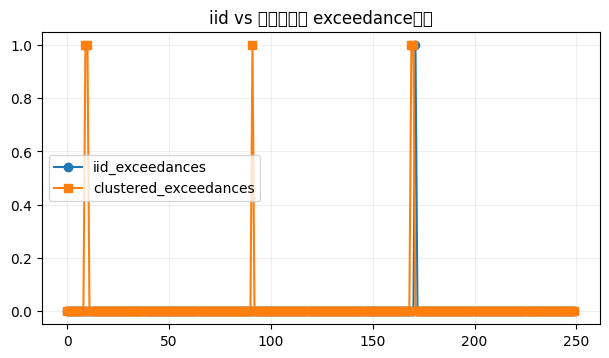

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("iid vs クラスタ型 exceedance系列")
ax.plot(data["exceedance_day"], data["iid_exceedances"], marker="o", label="iid_exceedances")
ax.plot(data["exceedance_day"], data["clustered_exceedances"], marker="s", label="clustered_exceedances")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Kupiec POF size study（nominal 5%）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


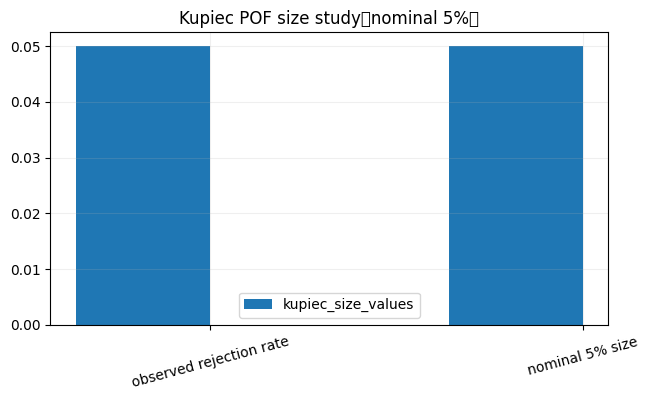

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Kupiec POF size study（nominal 5%）")
x = np.arange(len(data["kupiec_size_names"]))
ax.bar(x - .18, data["kupiec_size_values"], width=.36, label="kupiec_size_values")
ax.set_xticks(x, data["kupiec_size_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Basel traffic light：二項累積確率

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38917 (\N{CJK UNIFIED IDEOGRAPH-9805}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3

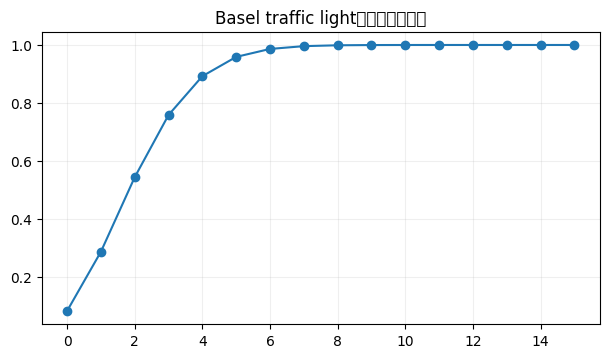

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Basel traffic light：二項累積確率")
ax.plot(data["traffic_light_x"], data["traffic_light_cumulative_prob"], marker="o")
ax.grid(alpha=.2)
plt.show()

## Basel traffic light：資本乗数

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36039 (\N{CJK UNIFIED IDEOGRAPH-8CC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20055 (\N{CJK UNIFIED IDEOGRAPH-4E57}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


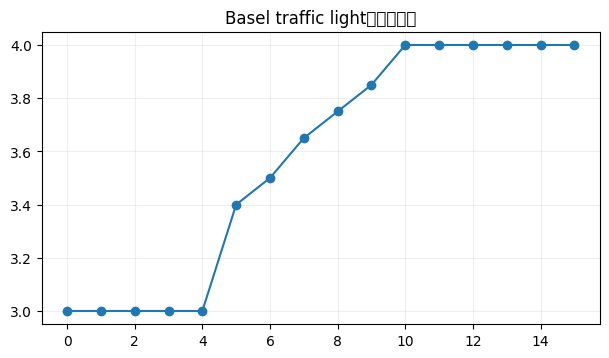

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Basel traffic light：資本乗数")
ax.plot(data["traffic_light_x"], data["traffic_light_multiplier"], marker="o")
ax.grid(alpha=.2)
plt.show()

## GARCHボラティリティ・クラスタリング

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12508 (\N{KATAKANA LETTER BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12451 (\N{KATAKANA LETTER SMALL I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12522 (\N{KATAKAN

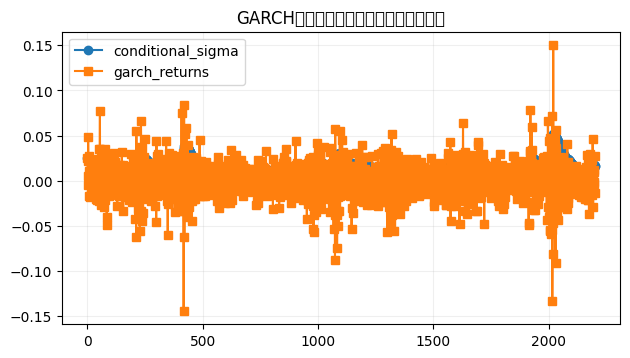

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("GARCHボラティリティ・クラスタリング")
ax.plot(data["return_day"], data["conditional_sigma"], marker="o", label="conditional_sigma")
ax.plot(data["return_day"], data["garch_returns"], marker="s", label="garch_returns")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## plain-HS vs FHS VaR forecast

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

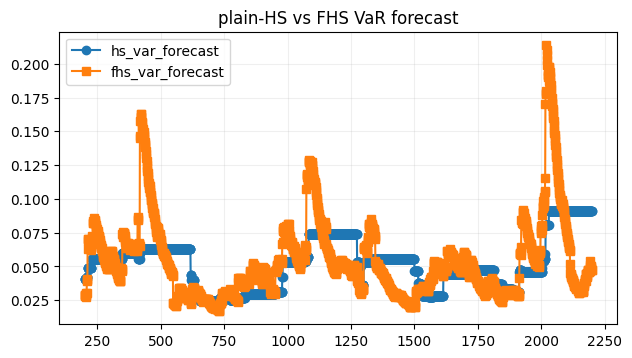

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("plain-HS vs FHS VaR forecast")
ax.plot(data["backtest_day"], data["hs_var_forecast"], marker="o", label="hs_var_forecast")
ax.plot(data["backtest_day"], data["fhs_var_forecast"], marker="s", label="fhs_var_forecast")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 被覆率：plain-HS vs FHS（目標 1%）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 6

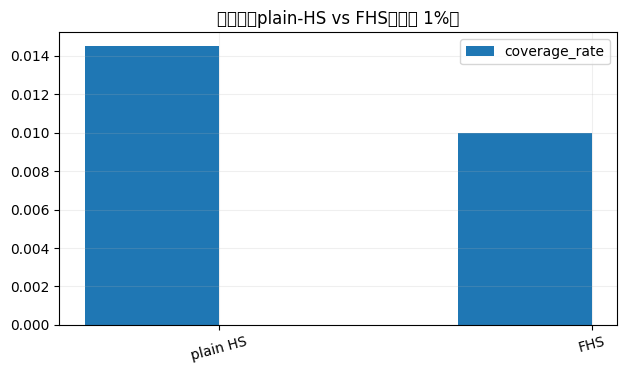

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("被覆率：plain-HS vs FHS（目標 1%）")
x = np.arange(len(data["coverage_names"]))
ax.bar(x - .18, data["coverage_rate"], width=.36, label="coverage_rate")
ax.set_xticks(x, data["coverage_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 平均超過関数（POT閾値診断）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36229 (\N{CJK UNIFIED IDEOGRAPH-8D85}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36942 (\N{CJK UNIFIED IDEOGRAPH-904E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarni

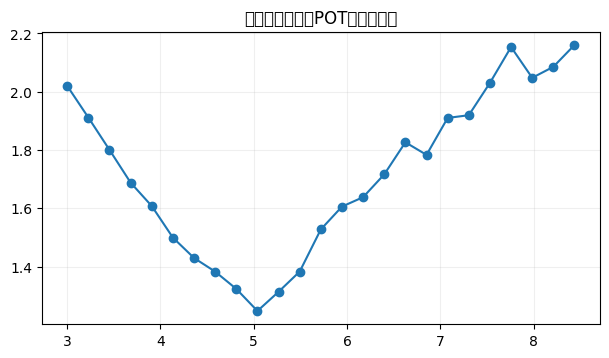

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("平均超過関数（POT閾値診断）")
ax.plot(data["mean_excess_threshold"], data["mean_excess_curve"], marker="o")
ax.grid(alpha=.2)
plt.show()

## EVT vs 経験 VaR ladder

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39443 (\N{CJK UNIFIED IDEOGRAPH-9A13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


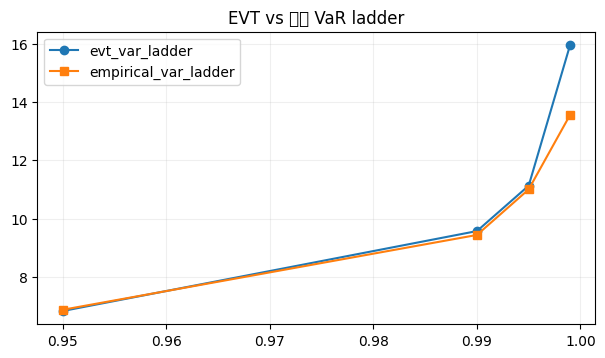

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("EVT vs 経験 VaR ladder")
ax.plot(data["evt_quantile_alpha"], data["evt_var_ladder"], marker="o", label="evt_var_ladder")
ax.plot(data["evt_quantile_alpha"], data["empirical_var_ladder"], marker="s", label="empirical_var_ladder")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## component vs incremental VaR

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

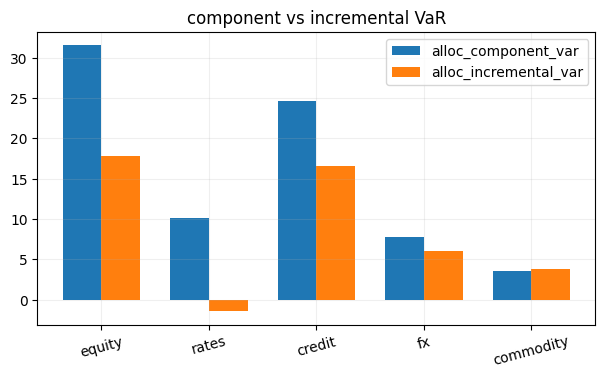

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("component vs incremental VaR")
x = np.arange(len(data["asset_names"]))
ax.bar(x - .18, data["alloc_component_var"], width=.36, label="alloc_component_var")
ax.bar(x + .18, data["alloc_incremental_var"], width=.36, label="alloc_incremental_var")
ax.set_xticks(x, data["asset_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## simulation Euler ES 寄与

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


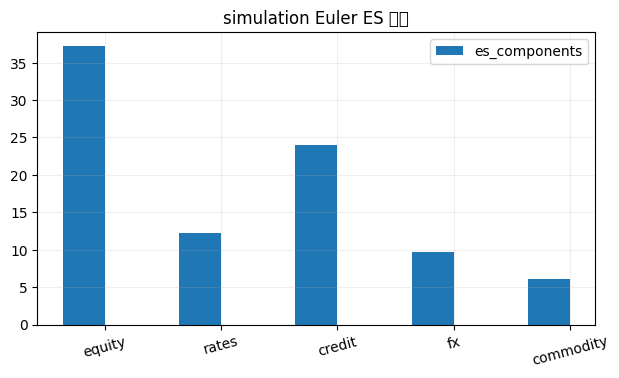

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("simulation Euler ES 寄与")
x = np.arange(len(data["asset_names"]))
ax.bar(x - .18, data["es_components"], width=.36, label="es_components")
ax.set_xticks(x, data["asset_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## P&L explain：delta-gamma-vega 分解

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


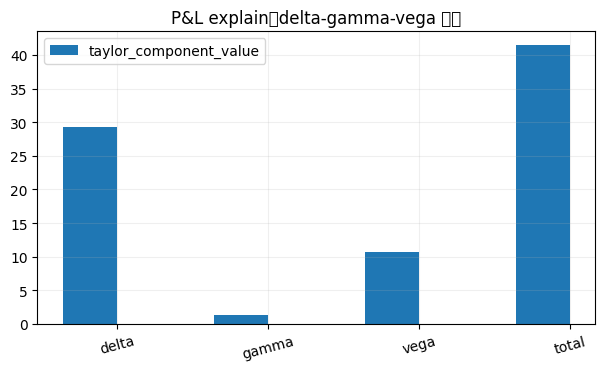

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("P&L explain：delta-gamma-vega 分解")
x = np.arange(len(data["taylor_component_names"]))
ax.bar(x - .18, data["taylor_component_value"], width=.36, label="taylor_component_value")
ax.set_xticks(x, data["taylor_component_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## limit utilization

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

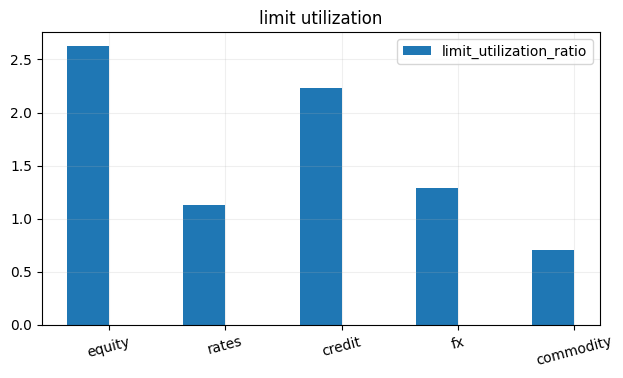

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("limit utilization")
x = np.arange(len(data["limit_names"]))
ax.bar(x - .18, data["limit_utilization_ratio"], width=.36, label="limit_utilization_ratio")
ax.set_xticks(x, data["limit_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Artifact恒等式の再計算検証

acceptance identityをcommitted artifactから直接recomputeし、JSONのフラグに依存せず主要な数値恒等式を確認する。

In [17]:
import math
m = manifest['metrics']
comp = data['alloc_component_var']
assert abs(float(comp.sum()) - m['alloc_normal_var']) <= 1e-12
es_check = (m['evt_var'] + m['gpd_beta_hat'] - m['gpd_xi_hat'] * m['evt_threshold']) / (1.0 - m['gpd_xi_hat'])
assert abs(m['evt_es'] - es_check) <= 1e-12
pm = data['pnl_matrix']
total = pm.sum(axis=1)
n = total.size
k = max(1, math.ceil(0.01 * n - 1e-9))
tail = np.argsort(total, kind='stable')[:k]
es_total = float((-total[tail]).mean())
assert abs(float((-pm[tail].mean(axis=0)).sum()) - es_total) <= 1e-12
hs_rate = float(data['hs_violations'].mean())
fhs_rate = float(data['fhs_violations'].mean())
assert abs(fhs_rate - 0.01) < abs(hs_rate - 0.01)
dgv_res = abs(m['taylor_full_pnl'] - m['taylor_dgv_total'])
delta_res = abs(m['taylor_full_pnl'] - m['taylor_delta_only'])
assert dgv_res < delta_res
print('recomputed from artifact: Euler VaR add., EVT ES identity, sim Euler ES add., FHS coverage, Taylor ordering — all hold')

recomputed from artifact: Euler VaR add., EVT ES identity, sim Euler ES add., FHS coverage, Taylor ordering — all hold


## 演習

1. `kupiec_size_reject_flags` から棄却率を再計算し、n_obs を 250 に変えたときの離散性による size 歪みを議論せよ。
2. `clustered_exceedances` の Markov 遷移確率を推定し、Christoffersen 独立性 LR が iid 系列より大きくなる理由を説明せよ。
3. `mean_excess_threshold` に対する `mean_excess_curve` の傾きから GPD の $\xi/(1-\xi)$ を読み取り、`gpd_xi_hat` と比較せよ。
4. `pnl_matrix` の尾部シナリオ集合を取り出し、`es_components` の加法性 $\sum_i CES_i = ES_{total}$ を手計算で確認せよ。
5. `factor_moves`・`vol_moves` を半分にしたとき、delta-only 残差と delta-gamma-vega 残差の縮小率の違い（線形 vs 二次）を予測し、`taylor_*_half` で検算せよ。

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [18]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Kupiec (1995); Christoffersen (1998); BCBS (1996); Barone-Adesi, Giannopoulos & Vosper (1999); McNeil & Frey (2000); Tasche (1999).

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。